# PFG - Análise Comparativa de Arquiteturas de Deep Learning para Predição de Tráfego em Redes 5G
## Etapa 1 - Pré-processamento e Agregação

Objetivo: a partir dos logs individuais de requisições, gerar uma série temporal multivariada com a contagem de requisições por hora para cada `Slice Type` (eMBB, URLLC, mMTC).

Saída esperada: DataFrame indexado pelo tempo (hora) com 3 colunas numéricas.

### 0. Dependências e montagem do Google Drive

In [ ]:
# Instalação de dependências (Google Colab já traz a maioria)
!pip install -q pandas numpy matplotlib scikit-learn torch "transformers>=4.40" pmdarima statsmodels

In [ ]:
# Imports centralizados
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from transformers import PatchTSTConfig, PatchTSTForPrediction, PatchTSTForPretraining

import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
import os


DATA_PATH = os.path.join("data", "model_inputs.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Leitura do CSV

Observações sobre o arquivo:
- A primeira coluna é um índice anônimo (sem nome) — vamos descartá-la com `index_col=0`.
- `Day` está como nome do dia da semana (Monday..Sunday).
- `Time` é a hora do dia (1..24).
- `Slice Type` é o rótulo alvo (eMBB, URLLC, mMTC).

In [ ]:
df = pd.read_csv(DATA_PATH, index_col=0, low_memory=False)
print('Shape bruto:', df.shape)
df.head()

/tmp/ipykernel_2623/4288763831.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data, index_col=0)


Shape bruto: (466739, 9)


,Use CaseType (Input 1),LTE/5G UE Category (Input 2),Technology Supported (Input 3),Day (Input4),Time (Input 5),QCI (Input 6),Packet Loss Rate (Reliability),Packet Delay Budget (Latency),Slice Type (Output)
NaN,Smartphone,1,LTE/5G,Monday,1,1,"0,01",<50ms,eMBB
NaN,Smartphone,1,LTE/5G,Monday,1,2,"0,01",<50ms,eMBB
NaN,Smartphone,1,LTE/5G,Monday,1,3,"0,01",<50ms,eMBB
NaN,Smartphone,1,LTE/5G,Monday,1,4,"0,01",<50ms,eMBB
NaN,Smartphone,1,LTE/5G,Monday,1,65,"0,01",<50ms,eMBB


In [ ]:
# Verificações rápidas
print('Colunas:', list(df.columns))
print('\nValores únicos de Day:', df['Day (Input4)'].unique())
print('Valores únicos de Time:', sorted(df['Time (Input 5)'].unique()))
print('Valores únicos de Slice Type:', df['Slice Type (Output)'].unique())
print('\nNulos por coluna:')
print(df.isna().sum())

Colunas: ['Use CaseType (Input 1)', 'LTE/5G UE Category (Input 2)', 'Technology Supported (Input 3)', 'Day (Input4)', 'Time (Input 5)', 'QCI (Input 6)', 'Packet Loss Rate (Reliability)', 'Packet Delay Budget (Latency)', 'Slice Type (Output)']

Valores únicos de Day: ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
Valores únicos de Time: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Valores únicos de Slice Type: ['eMBB' 'mMTC' 'URLLC']

Nulos por coluna:
Use CaseType (Input 1)            0
LTE/5G UE Category (Input 2)      0
Technology Supported (Input 3)    0
Day (Input4)                      0
Time (Input 5)                    0
QCI (Input 6)                     0
Packet Loss Rate (Reliability)   

### 2. Construção de um índice temporal contínuo

Convertendo o nome do dia da semana em um inteiro 0..6 e combinando com a hora para gerar `hour_index = day_of_week * 24 + (time - 1)`.

Assim teremos 7 * 24 = **168 timestamps** cobrindo uma semana completa, ordenados cronologicamente.

In [ ]:
day_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

df['day_of_week'] = df['Day (Input4)'].map(day_map)
df['hour_of_day'] = df['Time (Input 5)'].astype(int) - 1  # passa para 0..23
df['hour_index']  = df['day_of_week'] * 24 + df['hour_of_day']

# Sanity check
assert df['day_of_week'].notna().all(), 'Algum nome de dia não foi mapeado.'
assert df['hour_of_day'].between(0, 23).all(), 'Hora fora do intervalo 0..23.'
print('hour_index range:', df['hour_index'].min(), '->', df['hour_index'].max())

hour_index range: 0 -> 166


### 3. Agregação: contagem de requisições por hora e por slice

Cada linha do CSV representa uma requisição. Logo, `groupby + size` retorna a contagem desejada. O `pivot` transforma os tipos de slice em colunas.

In [ ]:
agg = (
    df.groupby(['hour_index', 'Slice Type (Output)'])
      .size()
      .unstack(fill_value=0)
      .rename_axis(columns=None)
)

# Garante todas as horas da semana presentes (caso alguma combinação não tenha registros)
full_index = pd.RangeIndex(start=0, stop=7 * 24, name='hour_index')
agg = agg.reindex(full_index, fill_value=0)

# Garante as três colunas mesmo se alguma faltar
for col in ['eMBB', 'URLLC', 'mMTC']:
    if col not in agg.columns:
        agg[col] = 0
agg = agg[['eMBB', 'URLLC', 'mMTC']].astype(np.int64)

print('Shape agregado:', agg.shape)
agg.head(10)

Shape agregado: (168, 3)


,eMBB,URLLC,mMTC
hour_index,,,
0,780,1300,819
1,780,1300,819
2,780,1300,819
3,780,1300,819
4,780,1300,819
5,780,1300,819
6,780,1300,819
7,780,1300,819
8,780,1300,819


In [ ]:
agg.describe()

,eMBB,URLLC,mMTC
count,168.000000,168.000000,168.000000
mean,747.500000,1245.833333,784.875000
std,156.468321,260.780534,164.291737
min,0.000000,0.000000,0.000000
25%,780.000000,1300.000000,819.000000
50%,780.000000,1300.000000,819.000000
75%,780.000000,1300.000000,819.000000
max,840.000000,1400.000000,882.000000


### 4. Visualização das três séries

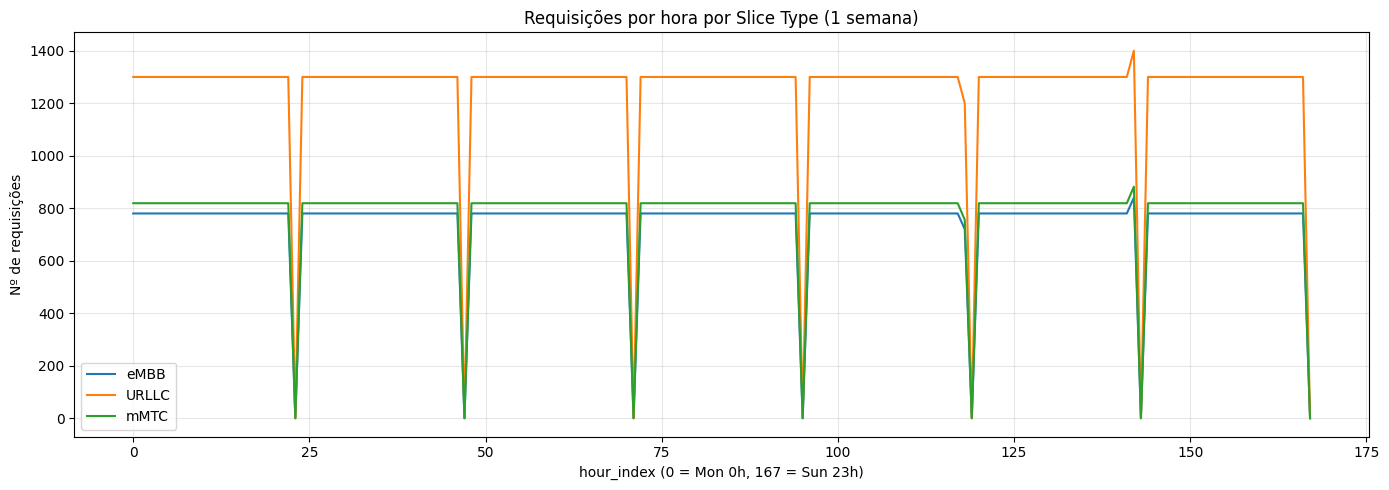

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
agg.plot(ax=ax)
ax.set_title('Requisições por hora por Slice Type (1 semana)')
ax.set_xlabel('hour_index (0 = Mon 0h, 167 = Sun 23h)')
ax.set_ylabel('Nº de requisições')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Resultado

`agg` é o DataFrame final que será usado nas próximas etapas (split, normalização, janelamento e modelagem):

- Índice: `hour_index` (inteiro contínuo, ordenado cronologicamente).
- Colunas numéricas: `eMBB`, `URLLC`, `mMTC` — contagem de requisições por hora.

In [ ]:
agg.tail()

,eMBB,URLLC,mMTC
hour_index,,,
163,780,1300,819
164,780,1300,819
165,780,1300,819
166,780,1300,819
167,0,0,0


## Etapa 2 - Divisão Treino/Teste (Sequencial)

Por se tratar de série temporal, a divisão **deve ser cronológica** (sem `shuffle`). Usaremos 70% das horas para treino e 30% para teste, mantendo a ordem temporal — assim evitamos que informações do futuro contaminem o treino.

In [ ]:
TRAIN_RATIO = 0.70

n_total = len(agg)
n_train = int(np.floor(n_total * TRAIN_RATIO))
n_test  = n_total - n_train

train_df = agg.iloc[:n_train].copy()
test_df  = agg.iloc[n_train:].copy()

print(f'Total de horas:   {n_total}')
print(f'Treino (70%):     {len(train_df)}  -> hour_index {train_df.index.min()}..{train_df.index.max()}')
print(f'Teste  (30%):     {len(test_df)}   -> hour_index {test_df.index.min()}..{test_df.index.max()}')

# Sanity checks
assert len(train_df) + len(test_df) == n_total
assert train_df.index.max() < test_df.index.min(), 'Sobreposição temporal entre treino e teste!'

Total de horas:   168
Treino (70%):     117  -> hour_index 0..116
Teste  (30%):     51   -> hour_index 117..167


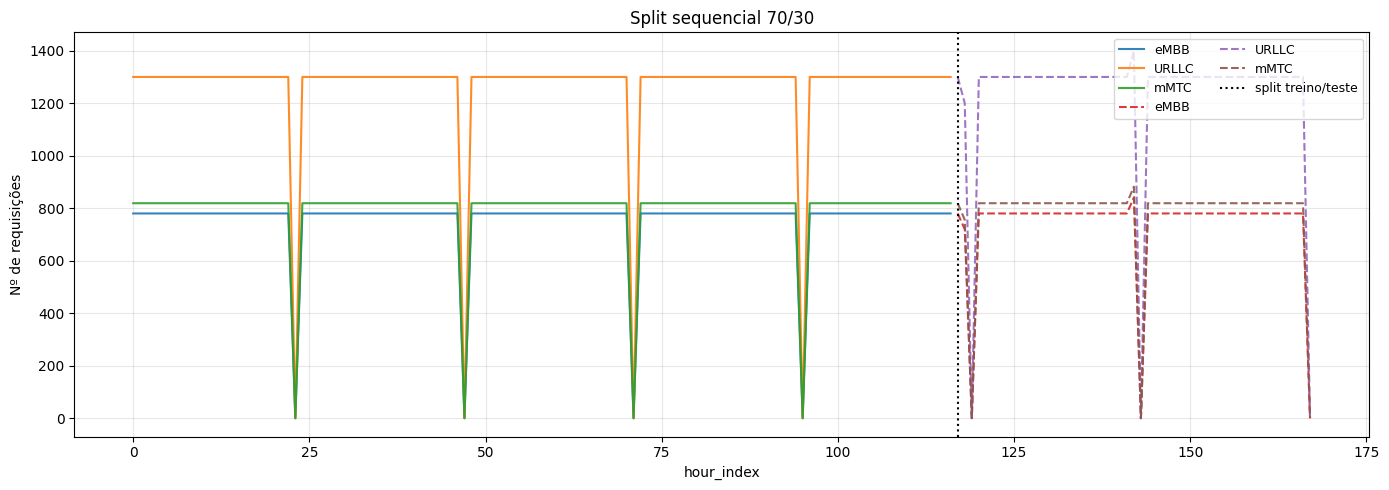

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
train_df.plot(ax=ax, alpha=0.9)
test_df.plot(ax=ax, linestyle='--', alpha=0.9)
ax.axvline(test_df.index.min(), color='k', linestyle=':', label='split treino/teste')
ax.set_title('Split sequencial 70/30')
ax.set_xlabel('hour_index')
ax.set_ylabel('Nº de requisições')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Etapa 3 - Normalização (Z-score)

Aplicamos o `StandardScaler` (média 0, desvio 1) por coluna. Para evitar **data leakage**:

- `.fit()` é executado **apenas no conjunto de treino**.
- O mesmo scaler (com a média e desvio aprendidos no treino) é usado para `.transform()` no treino e no teste.
- Guardamos o objeto `scaler` para fazer o `inverse_transform` na Etapa 6 (avaliação na escala real).

In [ ]:
FEATURES = ['eMBB', 'URLLC', 'mMTC']

scaler = StandardScaler()
scaler.fit(train_df[FEATURES].values)  # fit SOMENTE no treino

train_scaled = scaler.transform(train_df[FEATURES].values)
test_scaled  = scaler.transform(test_df[FEATURES].values)

# Mantém em DataFrame para inspeção (preserva o índice temporal)
train_scaled_df = pd.DataFrame(train_scaled, index=train_df.index, columns=FEATURES)
test_scaled_df  = pd.DataFrame(test_scaled,  index=test_df.index,  columns=FEATURES)

print('Médias aprendidas (treino):', dict(zip(FEATURES, scaler.mean_.round(4))))
print('Desvios aprendidos (treino):', dict(zip(FEATURES, scaler.scale_.round(4))))
print('\nShape treino normalizado:', train_scaled.shape)
print('Shape teste  normalizado:', test_scaled.shape)

Médias aprendidas (treino): {'eMBB': np.float64(753.3333), 'URLLC': np.float64(1255.5556), 'mMTC': np.float64(791.0)}
Desvios aprendidos (treino): {'eMBB': np.float64(141.7353), 'URLLC': np.float64(236.2255), 'mMTC': np.float64(148.822)}

Shape treino normalizado: (117, 3)
Shape teste  normalizado: (51, 3)


In [ ]:
# Validação rápida: no treino, média ~0 e desvio ~1 por coluna
print('Treino  -> média:', train_scaled.mean(axis=0).round(4),
      '| desvio:', train_scaled.std(axis=0).round(4))
print('Teste   -> média:', test_scaled.mean(axis=0).round(4),
      '| desvio:', test_scaled.std(axis=0).round(4),
      '   (não precisa ser 0/1 — esperado)')

# Confirma que o inverse_transform reconstrói os valores originais do treino
recon = scaler.inverse_transform(train_scaled)
assert np.allclose(recon, train_df[FEATURES].values), 'inverse_transform falhou no treino'
print('\nOK: inverse_transform reconstrói os valores originais.')

Treino  -> média: [-0. -0. -0.] | desvio: [1. 1. 1.]
Teste   -> média: [-0.1356 -0.1356 -0.1356] | desvio: [1.2976 1.2976 1.2976]    (não precisa ser 0/1 — esperado)

OK: inverse_transform reconstrói os valores originais.


## Etapa 4 - Janelamento Deslizante (Sliding Windows)

Estratégia **Direct Multi-Step (DMS)**: o modelo recebe um histórico (`look_back`) e prevê **diretamente** todos os passos do horizonte (`horizon`) em uma única inferência — sem realimentar predições, evitando acúmulo de erros.

Para cada índice `t` válido, geramos:

- $X_t \in \mathbb{R}^{L \times C}$ — janela do histórico (`look_back = L` passos, `C` variáveis).
- $Y_t \in \mathbb{R}^{H \times C}$ — janela do futuro (`horizon = H` passos, `C` variáveis).

A função `make_sliding_windows` é genérica (recebe array `(T, C)` e devolve tensores `(N, L, C)` e `(N, H, C)`).

**Janelas de teste começando no 1º passo do conjunto de teste.** Para que a 1ª predição comece já em `test[0]`, anexamos as últimas `LOOK_BACK` horas do treino ao início do teste antes de janelar. Esta é a prática padrão em LTSF (Informer, PatchTST, DLinear) e **não introduz leakage**: o `StandardScaler` foi fitado só no treino, e esses pontos são usados apenas como histórico de entrada — nunca como alvo $Y$.

**Múltiplos horizontes (estado da arte).** Seguindo a prática dos benchmarks de LTSF, fixamos `look_back = 48` e avaliaremos **dois horizontes** em paralelo:

- **Teste 1**: `horizon = 12`
- **Teste 2**: `horizon = 24`

Para isso, encapsulamos a construção dos artefatos (X, Y, DataLoaders) numa função `build_experiment(horizon, ...)`, e materializamos um dicionário `EXPERIMENTS[h]` para cada horizonte. As Etapas 5 e 6 vão simplesmente iterar sobre essas chaves.

> **Observação sobre o tamanho do dataset**: o dataset cobre 1 semana (168 h). Treino tem 117 h e teste 51 h. Com `look_back=96` + `horizon=24` (=120) **não há janelas suficientes** em nenhum dos splits. Por isso, fixamos `look_back=48`; o exemplo "96/24" do enunciado fica preparado para quando houver mais dados.

In [ ]:
def make_sliding_windows(series: np.ndarray, look_back: int, horizon: int, stride: int = 1):
    """
    Gera janelas deslizantes para previsão multivariada multi-step (DMS).

    Parâmetros
    ----------
    series : np.ndarray, shape (T, C)
        Série temporal já normalizada. T = nº de passos, C = nº de variáveis.
    look_back : int
        Tamanho da janela de histórico (L).
    horizon : int
        Tamanho do horizonte de previsão (H).
    stride : int, default=1
        Passo entre janelas consecutivas.

    Retorna
    -------
    X : np.ndarray, shape (N, L, C) — históricos.
    Y : np.ndarray, shape (N, H, C) — futuros (alvos).
    """
    if series.ndim != 2:
        raise ValueError(f'series deve ter shape (T, C); recebido {series.shape}')
    T, C = series.shape
    max_start = T - look_back - horizon + 1
    if max_start <= 0:
        raise ValueError(
            f'Série muito curta: T={T}, look_back={look_back}, horizon={horizon} '
            f'-> nenhuma janela possível.'
        )

    starts = np.arange(0, max_start, stride)
    N = len(starts)
    X = np.empty((N, look_back, C), dtype=np.float32)
    Y = np.empty((N, horizon,   C), dtype=np.float32)
    for i, s in enumerate(starts):
        X[i] = series[s : s + look_back]
        Y[i] = series[s + look_back : s + look_back + horizon]
    return X, Y

In [ ]:
# Hiperparâmetros globais (compartilhados pelos experimentos)
LOOK_BACK  = 48
STRIDE     = 1
BATCH_SIZE = 32
HORIZONS   = [12, 24]   # Teste 1 e Teste 2

def build_experiment(horizon: int,
                     train_series: np.ndarray,
                     test_series: np.ndarray,
                     look_back: int = LOOK_BACK,
                     stride: int = STRIDE,
                     batch_size: int = BATCH_SIZE) -> dict:
    """
    Monta janelas e DataLoaders para um dado horizonte de previsão.

    - Treino: janelas geradas apenas com `train_series`.
    - Teste:  prepende as últimas `look_back` horas do treino ao teste, para que
              a 1ª predição comece no primeiro passo do conjunto de teste.
              Não há leakage (esses pontos só entram como X, nunca como Y).
    """
    X_tr, Y_tr = make_sliding_windows(train_series, look_back, horizon, stride)

    test_input = np.concatenate([train_series[-look_back:], test_series], axis=0)
    X_te, Y_te = make_sliding_windows(test_input, look_back, horizon, stride)

    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(Y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(Y_te))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    return {
        'horizon':      horizon,
        'look_back':    look_back,
        'X_train':      X_tr, 'Y_train': Y_tr,
        'X_test':       X_te, 'Y_test':  Y_te,
        'train_loader': train_loader,
        'test_loader':  test_loader,
    }

# Materializa os dois experimentos
EXPERIMENTS = {h: build_experiment(h, train_scaled, test_scaled) for h in HORIZONS}

for h, exp in EXPERIMENTS.items():
    print(f'[H={h:>2}] X_train={exp["X_train"].shape}  Y_train={exp["Y_train"].shape}'
          f'   |   X_test={exp["X_test"].shape}  Y_test={exp["Y_test"].shape}')

[H=12] X_train=(58, 48, 3)  Y_train=(58, 12, 3)   |   X_test=(40, 48, 3)  Y_test=(40, 12, 3)
[H=24] X_train=(46, 48, 3)  Y_train=(46, 24, 3)   |   X_test=(28, 48, 3)  Y_test=(28, 24, 3)


In [ ]:
# Sanity check: inspeciona um batch de cada experimento
for h, exp in EXPERIMENTS.items():
    xb, yb = next(iter(exp['train_loader']))
    print(f'[H={h:>2}] batch X: {tuple(xb.shape)} {xb.dtype}   '
          f'batch Y: {tuple(yb.shape)} {yb.dtype}')

[H=12] batch X: (32, 48, 3) torch.float32   batch Y: (32, 12, 3) torch.float32
[H=24] batch X: (32, 48, 3) torch.float32   batch Y: (32, 24, 3) torch.float32


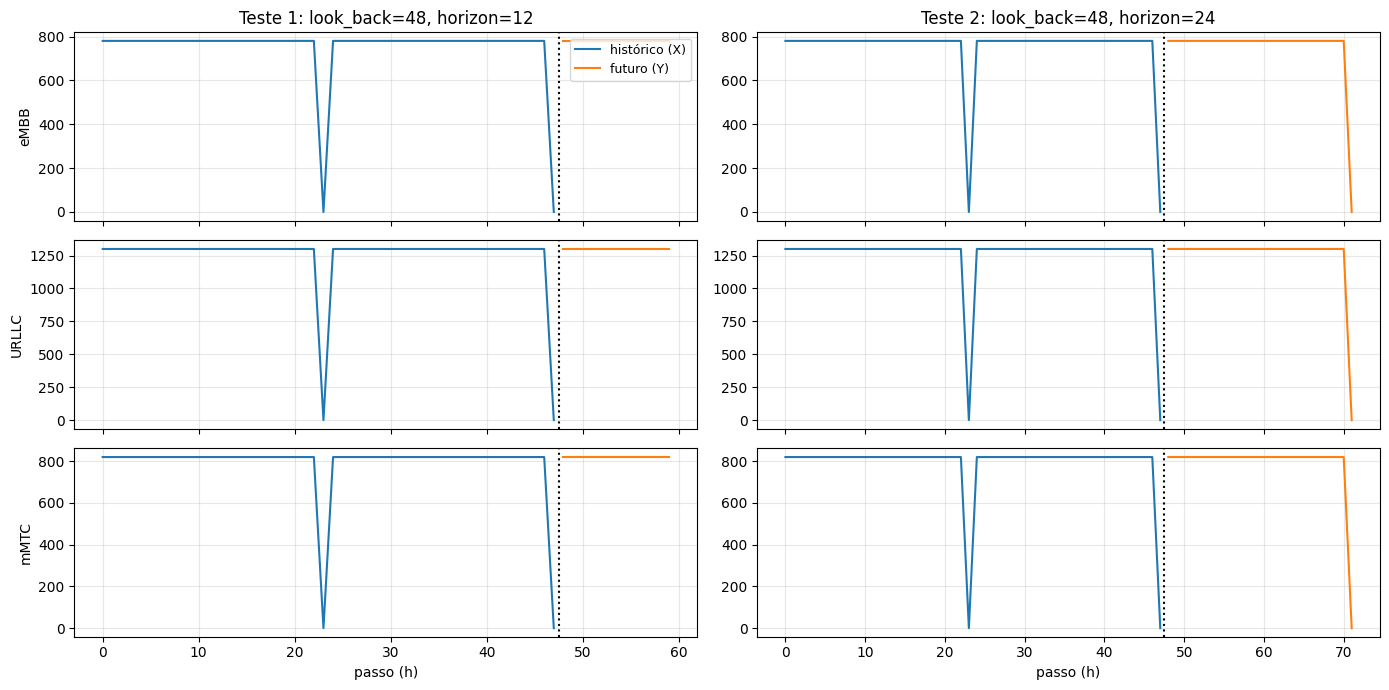

In [ ]:
# Visualização de uma janela (índice 0) de cada experimento — desnormalizada
sample_idx = 0

fig, axes = plt.subplots(len(FEATURES), len(EXPERIMENTS),
                         figsize=(7 * len(EXPERIMENTS), 7),
                         sharex='col')

for col, (h, exp) in enumerate(EXPERIMENTS.items()):
    L, H = exp['look_back'], exp['horizon']
    x_sample = scaler.inverse_transform(exp['X_train'][sample_idx])  # (L, C)
    y_sample = scaler.inverse_transform(exp['Y_train'][sample_idx])  # (H, C)
    t_hist = np.arange(L)
    t_fut  = np.arange(L, L + H)

    for i, feat in enumerate(FEATURES):
        ax = axes[i, col] if len(EXPERIMENTS) > 1 else axes[i]
        ax.plot(t_hist, x_sample[:, i], label='histórico (X)', color='tab:blue')
        ax.plot(t_fut,  y_sample[:, i], label='futuro (Y)',    color='tab:orange')
        ax.axvline(L - 0.5, color='k', linestyle=':')
        if col == 0:
            ax.set_ylabel(feat)
        ax.grid(True, alpha=0.3)

    top_ax = axes[0, col] if len(EXPERIMENTS) > 1 else axes[0]
    top_ax.set_title(f'Teste {col+1}: look_back={L}, horizon={H}')
    bot_ax = axes[-1, col] if len(EXPERIMENTS) > 1 else axes[-1]
    bot_ax.set_xlabel('passo (h)')

(axes[0, 0] if len(EXPERIMENTS) > 1 else axes[0]).legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Etapa 5 - Modelagem (PatchTST)

Nesta etapa, focamos exclusivamente no modelo principal:

- **PatchTST (oficial)** — integração mantida pelos autores na biblioteca `transformers` da Hugging Face (`PatchTSTForPrediction`). Arquitetura Transformer com *channel-independence* e *patches* temporais.

Os baselines (**ARIMA** e **CNN 1D adaptada a séries temporais**) serão treinados em uma etapa posterior, sob o **mesmo protocolo** (mesmo split, mesmo scaler, mesmas janelas e os mesmos dois horizontes `H ∈ {12, 24}`), para comparação justa.

O PatchTST é treinado nos **dois horizontes** (`H = 12` e `H = 24`), totalizando 2 runs. As predições no conjunto de teste são guardadas em `RESULTS` (escala normalizada) para a Etapa 6 (desnormalização + métricas).

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
NUM_CHANNELS = len(FEATURES)

Device: cpu


### 5.1 PatchTST (Hugging Face oficial) — wrapper parametrizado para Estudo de Ablação

Usa `PatchTSTForPrediction` (`transformers`). O *forward* recebe `past_values (B, L, C)` e retorna `prediction_outputs (B, H, C)`. Com `look_back=48`, usamos `patch_length=8` e `patch_stride=8` → 6 patches não-sobrepostos.

Na primeira rodada o PatchTST teve MSE muito alto (overfitting clássico em base pequena e altamente periódica). Para investigar **uma técnica por vez**, expomos abaixo os 3 hiperparâmetros-chave da literatura recente como argumentos do construtor:

- **`d_model`, `n_heads`, `n_layers`, `dropout`** — controlam a capacidade da rede (Ablação A: redução drástica para combater memorização de ruído).
- **`scaling`** — `None` desativa o Reversible Instance Norm interno (assumindo que já fizemos Z-score externo); `'std'` ativa o **RevIN** (Ablação B), que renormaliza cada janela e a desnormaliza na saída — robusto a *distribution shift* entre slices.
- **`positional_encoding_type`** — força explicitamente o tipo de Positional Encoding temporal (Ablação C: `'sincos'` reforça a informação geométrica de posição que a auto-atenção tende a diluir em datasets pequenos).

In [ ]:
class PatchTST(nn.Module):
    """Wrapper sobre PatchTSTForPrediction parametrizável para o Estudo de Ablação.

    Os hiperparâmetros que afetam capacidade (`d_model`, `n_layers`, `n_heads`,
    `dropout`), normalização interna (`scaling` — RevIN quando `'std'`) e o
    Positional Encoding temporal (`positional_encoding_type`) são expostos como
    argumentos, permitindo testar uma variação por vez sem reescrever a rede.

    Forward: (B, L, C) -> (B, H, C).
    """
    def __init__(self, look_back: int, horizon: int, num_channels: int,
                 patch_length: int = 8, patch_stride: int = 8,
                 # --- capacidade arquitetural (Ablação A) ---
                 d_model: int = 64, n_heads: int = 4, n_layers: int = 2,
                 ffn_dim: int = 128, dropout: float = 0.1,
                 # --- Reversible Instance Norm interna (Ablação B) ---
                 # None = sem RevIN (assume Z-score externo); 'std' = ativa RevIN
                 scaling=None,
                 # --- Positional Encoding temporal (Ablação C) ---
                 # None = default do HF; 'sincos'/'random'/'no' força explicitamente
                 positional_encoding_type: str = None):
        super().__init__()
        cfg_kwargs = dict(
            num_input_channels=num_channels,
            context_length=look_back,
            prediction_length=horizon,
            patch_length=patch_length,
            patch_stride=patch_stride,
            d_model=d_model,
            num_attention_heads=n_heads,
            num_hidden_layers=n_layers,
            ffn_dim=ffn_dim,
            dropout=dropout,
            head_dropout=dropout,
            scaling=scaling,
            do_mask_input=False,   # treino supervisionado direto (DMS)
        )
        if positional_encoding_type is not None:
            cfg_kwargs['positional_encoding_type'] = positional_encoding_type
        self.config = PatchTSTConfig(**cfg_kwargs)
        self.model  = PatchTSTForPrediction(self.config)

    def forward(self, x):  # x: (B, L, C)
        out = self.model(past_values=x)
        return out.prediction_outputs  # (B, H, C)

### 5.2 Loop de treino genérico

Treina qualquer `nn.Module` com interface `(B, L, C) -> (B, H, C)`. Mantemos a função genérica para que os baselines (CNN 1D) possam reutilizá-la sem alteração quando forem adicionados.

In [ ]:
def train_model(model: nn.Module, train_loader, num_epochs: int = 100,
                lr: float = 1e-3, device=DEVICE, verbose_every: int = 20) -> nn.Module:
    model = model.to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for epoch in range(1, num_epochs + 1):
        total, n = 0.0, 0
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            optim.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optim.step()
            total += loss.item() * xb.size(0); n += xb.size(0)
        if verbose_every and (epoch == 1 or epoch % verbose_every == 0 or epoch == num_epochs):
            print(f'  epoch {epoch:>3}/{num_epochs}  train MSE (norm): {total/n:.4f}')
    return model


@torch.no_grad()
def predict(model: nn.Module, loader, device=DEVICE):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        p = model(xb).cpu().numpy()
        preds.append(p); trues.append(yb.numpy())
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

### 5.3 Baseline: CNN 1D adaptada a séries temporais

CNN 1D *channel-independent* (mesma estratégia do PatchTST: cada slice é processada independentemente, compartilhando os pesos das convoluções). Pipeline:

1. Reshape `(B, L, C) -> (B*C, 1, L)` para tratar cada canal como uma série univariada.
2. Duas camadas `Conv1d` com `padding='same'` + `ReLU` para extrair padrões locais.
3. `Flatten` + `Linear(L * hidden_channels -> H)` produz a previsão direta (DMS) do horizonte.
4. Reshape de volta para `(B, H, C)`.

Hiperparâmetros conservadores (kernel=3, 32→32 canais), suficientes para servir de baseline forte sem competir em capacidade com o PatchTST.

In [ ]:
class CNN1D(nn.Module):
    """CNN 1D channel-independent para previsão multi-step direta (DMS).

    Forward: (B, L, C) -> (B, H, C).
    Cada canal é processado independentemente com convoluções 1D compartilhadas,
    e uma cabeça linear projeta o histórico para o horizonte completo.
    """
    def __init__(self, look_back: int, horizon: int, num_channels: int,
                 hidden_channels: int = 32, kernel_size: int = 3, dropout: float = 0.1):
        super().__init__()
        self.look_back    = look_back
        self.horizon      = horizon
        self.num_channels = num_channels

        pad = kernel_size // 2  # 'same' padding (kernel ímpar)
        self.conv = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Linear(hidden_channels * look_back, horizon)

    def forward(self, x):  # x: (B, L, C)
        B, L, C = x.shape
        # channel-independent: trata cada canal como amostra univariada
        x = x.permute(0, 2, 1).reshape(B * C, 1, L)   # (B*C, 1, L)
        x = self.conv(x)                              # (B*C, hidden, L)
        x = x.reshape(B * C, -1)                      # (B*C, hidden*L)
        x = self.head(x)                              # (B*C, H)
        x = x.reshape(B, C, self.horizon).permute(0, 2, 1)  # (B, H, C)
        return x

### 5.3.1 Outras arquiteturas neurais (LSTM e DLinear)

Para o estudo comparativo, adicionamos duas arquiteturas que cobrem famílias diferentes da literatura LTSF, ambas com a mesma interface `(B, L, C) -> (B, H, C)`:

- **`LSTMModel`** — recorrência clássica. 2 camadas `nn.LSTM` (`hidden_size=64`, `batch_first=True`) processando os 3 canais conjuntamente (multivariada). Pega o último estado oculto e projeta com `Linear(hidden, H*C)`, depois remodela para `(B, H, C)`. Útil como ponto de comparação para a auto-atenção do PatchTST.
- **`DLinear`** (Zeng et al., 2022) — rede *linear* mais forte do estado da arte LTSF. Faz decomposição por média móvel (`kernel_size=25`, padding por reflexão) separando a entrada em **tendência** e **resto** (resíduo sazonal); cada componente é projetado por uma `Linear(L, H)` independente *channel-independent*; a saída é a soma. Apesar de ser literalmente "duas regressões lineares", em séries pequenas e altamente periódicas costuma bater Transformers — exatamente o caso do nosso dataset.

Ambas serão treinadas pelo mesmo `train_model` que CNN1D e PatchTST (mesmas épocas, lr e seed) — comparação direta.

In [ ]:
class LSTMModel(nn.Module):
    """LSTM multivariada para previsão multi-step direta (DMS).

    Forward: (B, L, C) -> (B, H, C).
    Estratégia: empilha 2 camadas LSTM com input_size=C (multivariada conjunta).
    A saída do ÚLTIMO passo de tempo (h_t do topo) é projetada por uma única
    camada linear para H*C, e remodelada para (B, H, C).
    """
    def __init__(self, look_back: int, horizon: int, num_channels: int,
                 hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.horizon      = horizon
        self.num_channels = num_channels
        self.lstm = nn.LSTM(
            input_size  = num_channels,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, horizon * num_channels)

    def forward(self, x):                         # x: (B, L, C)
        out, _ = self.lstm(x)                     # (B, L, hidden)
        last   = out[:, -1, :]                    # (B, hidden)  — último passo
        proj   = self.head(last)                  # (B, H*C)
        return proj.view(-1, self.horizon, self.num_channels)  # (B, H, C)


class _MovingAvg(nn.Module):
    """Média móvel 1D com padding por replicação dos extremos para preservar L.

    Forward: (B, L, C) -> (B, L, C). Saída é a TENDÊNCIA da série.
    """
    def __init__(self, kernel_size: int = 25):
        super().__init__()
        if kernel_size % 2 == 0:
            raise ValueError('kernel_size deve ser ímpar para padding simétrico.')
        self.kernel_size = kernel_size
        self.pad = (kernel_size - 1) // 2
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):                          # x: (B, L, C)
        front = x[:, :1, :].repeat(1, self.pad, 1) # replica o 1º passo
        end   = x[:, -1:, :].repeat(1, self.pad, 1)# replica o último passo
        x = torch.cat([front, x, end], dim=1)      # (B, L+2*pad, C)
        x = x.permute(0, 2, 1)                     # AvgPool1d espera (B, C, L)
        x = self.avg(x)                            # (B, C, L)
        return x.permute(0, 2, 1)                  # (B, L, C)


class DLinear(nn.Module):
    """DLinear (Zeng et al., 2022): decomposição por média móvel + 2 lineares.

    Forward: (B, L, C) -> (B, H, C).
    Pipeline:
      1. trend     = MovingAvg(x);  remainder = x - trend
      2. Linear(L, H) compartilhada por canal (channel-independent) para cada componente
      3. saída = Linear_trend(trend) + Linear_remainder(remainder)
    """
    def __init__(self, look_back: int, horizon: int, num_channels: int,
                 kernel_size: int = 25):
        super().__init__()
        self.decomp           = _MovingAvg(kernel_size=kernel_size)
        self.linear_trend     = nn.Linear(look_back, horizon)
        self.linear_remainder = nn.Linear(look_back, horizon)

    def forward(self, x):                                  # x: (B, L, C)
        trend     = self.decomp(x)                          # (B, L, C)
        remainder = x - trend                               # (B, L, C)
        # channel-independent: cada canal vira uma "amostra" para o Linear(L, H)
        trend     = trend.permute(0, 2, 1)                  # (B, C, L)
        remainder = remainder.permute(0, 2, 1)              # (B, C, L)
        out = self.linear_trend(trend) + self.linear_remainder(remainder)  # (B, C, H)
        return out.permute(0, 2, 1)                         # (B, H, C)

### 5.4 Estudo de Ablação do PatchTST + treino do baseline neural (CNN1D)

Mesmo protocolo de treino (épocas, otimizador, lr, mesma seed) para todas as variantes — a **única** coisa que muda em cada run são os hiperparâmetros listados em `PATCHTST_ABLATIONS`. Isso garante que qualquer variação no MSE/MAE seja atribuível à técnica testada.

Sequência testada (acumulativa):

1. **`PatchTST_Original`** — `d_model=64, n_layers=2, n_heads=4, dropout=0.1, scaling=None` (linha de base que falhou na primeira rodada).
2. **`PatchTST_A_small`** — Ablação A. Reduz drasticamente a capacidade: `d_model=16, n_layers=1, n_heads=2, dropout=0.3`. Mantém `scaling=None`.
3. **`PatchTST_AB_revin`** — Ablação A + B. Mantém a rede reduzida e ativa o **RevIN** (`scaling='std'`).
4. **`PatchTST_ABC_sincos`** — Ablação A + B + C. Mantém A+B e força explicitamente `positional_encoding_type='sincos'`.

Resultados ficam em `RESULTS[(name, horizon)]` no mesmo formato `(N, H, C)` dos outros modelos — a Etapa 6 calcula MSE/MAE de cada um automaticamente. Em paralelo treinamos `CNN1D` como baseline neural de comparação.

In [ ]:
NUM_EPOCHS = 100
LR         = 1e-3

# =====================================================================
# Estudo de Ablação do PatchTST
# ---------------------------------------------------------------------
# Cada entrada acumula UMA mudança nova em relação à anterior. Com isso
# isolamos o efeito de cada técnica no MSE/MAE:
#
#   1) PatchTST_Original  -> baseline com hiperparâmetros do paper
#   2) PatchTST_A_small   -> + Ablação A: redução drástica de capacidade
#                           (d_model=16, n_layers=1, n_heads=2, dropout=0.3)
#                           (mantém scaling=None)
#   3) PatchTST_AB_revin  -> + Ablação B: ativa RevIN (scaling='std')
#   4) PatchTST_ABC_sincos-> + Ablação C: força positional_encoding_type='sincos'
#
# Todas as 4 variantes são treinadas nos 2 horizontes (12, 24) e os
# resultados gravados em RESULTS[(name, h)] no formato (N, H, C), no
# mesmo padrão dos outros modelos — a Etapa 6 calcula MSE/MAE
# automaticamente para cada uma e podemos comparar lado a lado.
# =====================================================================
PATCHTST_ABLATIONS = {
    # 1) Modelo Original (Padrão)
    'PatchTST_Original': dict(
        d_model=64, n_heads=4, n_layers=2, dropout=0.1,
        scaling=None, positional_encoding_type=None,
    ),
    # 2) Ablação A — Redução drástica (combate ao overfitting)
    'PatchTST_A_small': dict(
        d_model=16, n_heads=2, n_layers=1, dropout=0.3,
        scaling=None, positional_encoding_type=None,
    ),
    # 3) Ablação A + B — Mantém rede reduzida e ATIVA RevIN
    'PatchTST_AB_revin': dict(
        d_model=16, n_heads=2, n_layers=1, dropout=0.3,
        scaling='std', positional_encoding_type=None,
    ),
    # 4) Ablação A + B + C — Reforça T-PE (sincos) explicitamente
    'PatchTST_ABC_sincos': dict(
        d_model=16, n_heads=2, n_layers=1, dropout=0.3,
        scaling='std', positional_encoding_type='sincos',
    ),
}

# Baselines neurais que NÃO entram no estudo de ablação (treino padrão).
# Mantidos para comparação justa nas tabelas finais.
NEURAL_BASELINES = {
    'CNN1D':   lambda L, H: CNN1D(look_back=L, horizon=H, num_channels=NUM_CHANNELS),
    'LSTM':    lambda L, H: LSTMModel(look_back=L, horizon=H, num_channels=NUM_CHANNELS,
                                      hidden_size=64, num_layers=2, dropout=0.1),
    'DLinear': lambda L, H: DLinear(look_back=L, horizon=H, num_channels=NUM_CHANNELS,
                                    kernel_size=25),
}

RESULTS = {}  # (model_name, horizon) -> dict(model, preds_scaled, trues_scaled, [config])

# --- 1) Treina cada variante do PatchTST (Estudo de Ablação) ---------
for ablation_name, cfg in PATCHTST_ABLATIONS.items():
    for h, exp in EXPERIMENTS.items():
        key = (ablation_name, h)
        print(f'\n=== {ablation_name}  |  look_back={exp["look_back"]}  horizon={h} ===')
        print(f'  config: {cfg}')
        torch.manual_seed(SEED)  # mesma init para cada run -> comparação justa
        model = PatchTST(
            look_back   = exp['look_back'],
            horizon     = h,
            num_channels= NUM_CHANNELS,
            **cfg,
        )
        model = train_model(model, exp['train_loader'],
                            num_epochs=NUM_EPOCHS, lr=LR, verbose_every=20)
        preds, trues = predict(model, exp['test_loader'])
        RESULTS[key] = {
            'model':         model,
            'preds_scaled':  preds,   # (N, H, C) escala normalizada
            'trues_scaled':  trues,   # (N, H, C) escala normalizada
            'config':        cfg,     # registro da configuração testada
        }
        print(f'  -> preds shape: {preds.shape}')

# --- 2) Treina baselines neurais (CNN1D) -----------------------------
for model_name, factory in NEURAL_BASELINES.items():
    for h, exp in EXPERIMENTS.items():
        key = (model_name, h)
        print(f'\n=== Treinando {model_name}  |  look_back={exp["look_back"]}  horizon={h} ===')
        torch.manual_seed(SEED)
        model = factory(exp['look_back'], h)
        model = train_model(model, exp['train_loader'],
                            num_epochs=NUM_EPOCHS, lr=LR, verbose_every=20)
        preds, trues = predict(model, exp['test_loader'])
        RESULTS[key] = {
            'model':         model,
            'preds_scaled':  preds,
            'trues_scaled':  trues,
        }
        print(f'  -> preds shape: {preds.shape}')


=== PatchTST_Original  |  look_back=48  horizon=12 ===
  config: {'d_model': 64, 'n_heads': 4, 'n_layers': 2, 'dropout': 0.1, 'scaling': None, 'positional_encoding_type': None}
  epoch   1/100  train MSE (norm): 1.0093
  epoch  20/100  train MSE (norm): 0.7765
  epoch  40/100  train MSE (norm): 0.6097
  epoch  60/100  train MSE (norm): 0.3899
  epoch  80/100  train MSE (norm): 0.3461
  epoch 100/100  train MSE (norm): 0.2786
  -> preds shape: (40, 12, 3)

=== PatchTST_Original  |  look_back=48  horizon=24 ===
  config: {'d_model': 64, 'n_heads': 4, 'n_layers': 2, 'dropout': 0.1, 'scaling': None, 'positional_encoding_type': None}
  epoch   1/100  train MSE (norm): 1.2107
  epoch  20/100  train MSE (norm): 0.8882
  epoch  40/100  train MSE (norm): 0.8582
  epoch  60/100  train MSE (norm): 0.8449
  epoch  80/100  train MSE (norm): 0.8412
  epoch 100/100  train MSE (norm): 0.8543
  -> preds shape: (28, 24, 3)

=== PatchTST_A_small  |  look_back=48  horizon=12 ===
  config: {'d_model': 16,

### 5.4.1 PatchTST + SSL (pré-treino auto-supervisionado)

Variante extra do estudo de ablação que **acrescenta uma fase de pré-treino auto-supervisionado** antes do treino supervisionado, mantendo a mesma arquitetura da Ablação A+B+C (`d_model=16, n_layers=1, n_heads=2, dropout=0.3, scaling='std', PE='sincos'`).

Pipeline em duas etapas:

1. **Etapa A — Pretraining (mascarado)**: instancia `PatchTSTForPretraining` com `do_mask_input=True`, `mask_type='random'` e `random_mask_ratio=0.5`. A loss interna do HuggingFace é a reconstrução dos *patches* mascarados — não usa o `Y_train`, é totalmente auto-supervisionado.
2. **Etapa B — Fine-tuning (supervisionado)**: cria `PatchTSTForPrediction` (`do_mask_input=False`) e **transfere o `state_dict` do backbone** pré-treinado (encoder + projeção de patches + RevIN). Em seguida, treina normalmente com MSE no horizonte usando o mesmo `train_model` dos demais.

Resultado salvo em `RESULTS[('PatchTST_SSL', h)]`, no mesmo formato `(N, H, C)` dos outros modelos.

In [ ]:
def train_patchtst_ssl(train_loader,
                       look_back: int,
                       horizon: int,
                       num_channels: int = NUM_CHANNELS,
                       # arquitetura compartilhada entre pretrain e fine-tune
                       d_model: int = 16, n_heads: int = 2, n_layers: int = 1,
                       ffn_dim: int = 128, dropout: float = 0.3,
                       patch_length: int = 8, patch_stride: int = 8,
                       # SSL
                       random_mask_ratio: float = 0.5,
                       pretrain_epochs: int = 50,
                       finetune_epochs: int = NUM_EPOCHS,
                       lr: float = LR,
                       device=DEVICE,
                       seed: int = SEED) -> nn.Module:
    """Pré-treino auto-supervisionado + fine-tuning do PatchTST.

    Etapa A — Pretraining: PatchTSTForPretraining com do_mask_input=True,
              mask_type='random', random_mask_ratio=0.5. Loss interna do HF
              é a reconstrução dos patches mascarados.
    Etapa B — Fine-tuning: cria PatchTSTForPrediction (do_mask_input=False)
              e transfere o state_dict do BACKBONE pré-treinado. Treina
              supervisionado com MSE no horizonte usando train_model().

    Retorna um nn.Module com a interface (B, L, C) -> (B, H, C),
    compatível com a função predict() existente.
    """
    common_cfg = dict(
        num_input_channels       = num_channels,
        context_length           = look_back,
        prediction_length        = horizon,
        patch_length             = patch_length,
        patch_stride             = patch_stride,
        d_model                  = d_model,
        num_attention_heads      = n_heads,
        num_hidden_layers        = n_layers,
        ffn_dim                  = ffn_dim,
        dropout                  = dropout,
        head_dropout             = dropout,
        scaling                  = 'std',
        positional_encoding_type = 'sincos',
    )

    # ---------- Etapa A: Pretraining (mascaramento aleatório) ----------
    torch.manual_seed(seed)
    pretrain_cfg = PatchTSTConfig(
        **common_cfg,
        do_mask_input     = True,
        mask_type         = 'random',
        random_mask_ratio = random_mask_ratio,
    )
    pretrain_model = PatchTSTForPretraining(pretrain_cfg).to(device)
    optim = torch.optim.Adam(pretrain_model.parameters(), lr=lr)
    pretrain_model.train()

    print(f'\n--- SSL Pretraining ({pretrain_epochs} épocas, mask_ratio={random_mask_ratio}) ---')
    for epoch in range(1, pretrain_epochs + 1):
        total, n = 0.0, 0
        for xb, _ in train_loader:                          # ignora o Y; é auto-supervisionado
            xb = xb.to(device)
            optim.zero_grad()
            out = pretrain_model(past_values=xb)            # HF calcula loss internamente
            loss = out.loss
            loss.backward()
            optim.step()
            total += loss.item() * xb.size(0); n += xb.size(0)
        if epoch == 1 or epoch % 10 == 0 or epoch == pretrain_epochs:
            print(f'  pre-epoch {epoch:>3}/{pretrain_epochs}  recon MSE: {total/n:.4f}')

    # ---------- Etapa B: Fine-tuning supervisionado ----------
    torch.manual_seed(seed)
    finetune_cfg = PatchTSTConfig(
        **common_cfg,
        do_mask_input = False,                              # ← desliga o masking
    )
    finetune_model = PatchTSTForPrediction(finetune_cfg).to(device)

    # Transferência de pesos do BACKBONE (encoder + projeções de patches).
    # Tanto PatchTSTForPretraining quanto PatchTSTForPrediction expõem o backbone
    # em .model (PatchTSTModel); a head específica de cada um (reconstrução vs
    # predição) NÃO é transferida — só os pesos do encoder.
    backbone_state = pretrain_model.model.state_dict()
    info = finetune_model.model.load_state_dict(backbone_state, strict=False)
    print(f'  -> backbone transferido | missing={len(info.missing_keys)}  '
          f'unexpected={len(info.unexpected_keys)}')

    # Wrapper para uniformizar a interface (B, L, C) -> (B, H, C),
    # idêntica à classe PatchTST que já existe no notebook.
    class _PatchTSTSSLWrapper(nn.Module):
        def __init__(self, hf_model):
            super().__init__()
            self.model = hf_model
        def forward(self, x):
            return self.model(past_values=x).prediction_outputs

    wrapped = _PatchTSTSSLWrapper(finetune_model)

    print(f'\n--- SSL Fine-tuning ({finetune_epochs} épocas, MSE no horizonte) ---')
    wrapped = train_model(wrapped, train_loader,
                          num_epochs=finetune_epochs, lr=lr,
                          device=device, verbose_every=20)
    return wrapped

In [ ]:
# Treina o PatchTST + SSL nos dois horizontes e grava em RESULTS.
for h, exp in EXPERIMENTS.items():
    key = ('PatchTST_SSL', h)
    print(f'\n=== {key[0]}  |  look_back={exp["look_back"]}  horizon={h} ===')
    model = train_patchtst_ssl(
        train_loader    = exp['train_loader'],
        look_back       = exp['look_back'],
        horizon         = h,
        pretrain_epochs = 50,             # ajuste se ver a recon MSE ainda caindo
        finetune_epochs = NUM_EPOCHS,
    )
    preds, trues = predict(model, exp['test_loader'])
    RESULTS[key] = {
        'model':        model,
        'preds_scaled': preds,
        'trues_scaled': trues,
    }
    print(f'  -> preds shape: {preds.shape}')


=== PatchTST_SSL  |  look_back=48  horizon=12 ===

--- SSL Pretraining (50 épocas, mask_ratio=0.5) ---
  pre-epoch   1/50  recon MSE: 0.9620
  pre-epoch  10/50  recon MSE: 0.9981
  pre-epoch  20/50  recon MSE: 1.0009
  pre-epoch  30/50  recon MSE: 0.9682
  pre-epoch  40/50  recon MSE: 0.9434
  pre-epoch  50/50  recon MSE: 0.9233
  -> backbone transferido | missing=0  unexpected=0

--- SSL Fine-tuning (100 épocas, MSE no horizonte) ---
  epoch   1/100  train MSE (norm): 1.0057
  epoch  20/100  train MSE (norm): 0.8754
  epoch  40/100  train MSE (norm): 0.8194
  epoch  60/100  train MSE (norm): 0.6893
  epoch  80/100  train MSE (norm): 0.6623
  epoch 100/100  train MSE (norm): 0.6541
  -> preds shape: (40, 12, 3)

=== PatchTST_SSL  |  look_back=48  horizon=24 ===

--- SSL Pretraining (50 épocas, mask_ratio=0.5) ---
  pre-epoch   1/50  recon MSE: 1.0070
  pre-epoch  10/50  recon MSE: 1.0254
  pre-epoch  20/50  recon MSE: 0.9092
  pre-epoch  30/50  recon MSE: 1.0455
  pre-epoch  40/50  re

### 5.4.2 Ensemble simples (CNN1D + LSTM)

Não treina nada — só combina via **média aritmética** as predições já gravadas em `RESULTS[('CNN1D', h)]` e `RESULTS[('LSTM', h)]`. Como ambos os arrays estão na escala normalizada e o `scaler.inverse_transform` é linear, a média no espaço Z-score é numericamente equivalente à média na escala real, então fazer o ensemble aqui é seguro.

In [ ]:
# Ensemble simples: média aritmética entre as predições de CNN1D e LSTM.
# Não treina nada — só combina o que já temos em RESULTS.
for h in HORIZONS:
    cnn_key, lstm_key = ('CNN1D', h), ('LSTM', h)
    if cnn_key not in RESULTS or lstm_key not in RESULTS:
        print(f'  Ensemble H={h} pulado: {cnn_key} ou {lstm_key} ausente em RESULTS.')
        continue
    cnn_preds  = RESULTS[cnn_key]['preds_scaled']
    lstm_preds = RESULTS[lstm_key]['preds_scaled']
    trues      = RESULTS[cnn_key]['trues_scaled']         # mesmo Y_test para os dois

    ensemble_preds = ((cnn_preds + lstm_preds) / 2.0).astype(np.float32)
    RESULTS[('Ensemble_CNN_LSTM', h)] = {
        'model':        None,                              # não há modelo treinado
        'preds_scaled': ensemble_preds,                    # (N, H, C)
        'trues_scaled': trues,                             # (N, H, C)
    }
    print(f'  Ensemble_CNN_LSTM H={h:>2}  ->  preds shape: {ensemble_preds.shape}')

  Ensemble_CNN_LSTM H=12  ->  preds shape: (40, 12, 3)
  Ensemble_CNN_LSTM H=24  ->  preds shape: (28, 24, 3)


### 5.5 Baseline: SARIMA (estatístico, univariado por canal, com sazonalidade diária)

Na primeira rodada, o `auto_arima` (sem componente sazonal) **falhou em capturar o ciclo diário** — a tabela do SNaive já evidencia que a série tem sazonalidade quase perfeita de período 24h. Refatoramos o baseline para **SARIMA** com:

- `seasonal=True` e `m=24` (período sazonal = 24h, 1 dia)
- `D=1` (uma diferenciação sazonal forçada, para remover o ciclo diário)

Os parâmetros não-sazonais `(p, d, q)` e os sazonais `(P, D, Q, m)` continuam sendo escolhidos automaticamente por AIC.

Protocolo (alinhado ao dos modelos neurais):

1. **Seleção de ordem** com `pmdarima.auto_arima(seasonal=True, m=24, D=1)` uma vez por canal sobre `train_scaled` — produz `(order, seasonal_order)` por slice.
2. Para **cada janela do teste**: para cada canal, ajusta um `SARIMAX(order, seasonal_order)` usando os `look_back` pontos da janela como histórico e prevê `H` passos à frente.

Assim, SARIMA enxerga **exatamente o mesmo histórico** que PatchTST/CNN1D em cada janela, mas agora com componente sazonal explícito. Os resultados são gravados em `RESULTS[('SARIMA', h)]` no mesmo formato `(N, H, C)` dos demais modelos.

In [ ]:
# 1) Seleção de ordem SARIMA (p,d,q)(P,D,Q,m) por canal usando auto_arima
#    no treino. m=24 = período sazonal diário (1 dia = 24h). D=1 força a
#    diferenciação sazonal — necessária porque o auto_arima anterior, sem
#    componente sazonal explícito, não capturou o ciclo diário.
SARIMA_ORDERS = {}
for c, feat in enumerate(FEATURES):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        auto = pm.auto_arima(
            train_scaled[:, c],
            seasonal=True,
            m=24,                     # período sazonal: 24h (ciclo diário)
            D=1,                      # diferenciação sazonal forçada
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            information_criterion='aic',
        )
    SARIMA_ORDERS[feat] = {
        'order':          auto.order,           # (p, d, q)
        'seasonal_order': auto.seasonal_order,  # (P, D, Q, m)
    }
    print(f'  {feat:>5}: order={auto.order}  seasonal_order={auto.seasonal_order}')

   eMBB: order=(0, 0, 0)  seasonal_order=(0, 1, 0, 24)
  URLLC: order=(0, 0, 0)  seasonal_order=(0, 1, 0, 24)
   mMTC: order=(0, 0, 0)  seasonal_order=(0, 1, 0, 24)


In [ ]:
def sarima_forecast_windows(X_test: np.ndarray, horizon: int,
                            orders: dict, feature_names: list) -> np.ndarray:
    """
    Para cada janela do teste e cada canal, ajusta SARIMAX com a ordem
    (p,d,q)(P,D,Q,m) pré-selecionada usando o histórico da janela e prevê
    `horizon` passos à frente.

    X_test : (N, L, C) — históricos das janelas de teste (escala normalizada).
    Retorna preds : (N, H, C) na escala normalizada.
    """
    N, L, C = X_test.shape
    preds = np.zeros((N, horizon, C), dtype=np.float32)
    for c, feat in enumerate(feature_names):
        order          = orders[feat]['order']
        seasonal_order = orders[feat]['seasonal_order']
        for i in range(N):
            history = X_test[i, :, c]
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    res = SARIMAX(history,
                                  order=order,
                                  seasonal_order=seasonal_order,
                                  enforce_stationarity=False,
                                  enforce_invertibility=False).fit(disp=False)
                fc = res.forecast(steps=horizon)
            except Exception:
                # fallback: repete o último valor (naive) se SARIMAX falhar
                fc = np.repeat(history[-1], horizon)
            preds[i, :, c] = np.asarray(fc, dtype=np.float32)
    return preds


for h, exp in EXPERIMENTS.items():
    key = ('SARIMA', h)
    print(f'\n=== SARIMA  |  look_back={exp["look_back"]}  horizon={h} ===')
    preds = sarima_forecast_windows(exp['X_test'], h, SARIMA_ORDERS, FEATURES)
    RESULTS[key] = {
        'model':        None,            # SARIMA não tem um único objeto persistente
        'preds_scaled': preds,           # (N, H, C)
        'trues_scaled': exp['Y_test'],   # (N, H, C)
    }
    print(f'  -> preds shape: {preds.shape}')


=== SARIMA  |  look_back=48  horizon=12 ===
  -> preds shape: (40, 12, 3)

=== SARIMA  |  look_back=48  horizon=24 ===
  -> preds shape: (28, 24, 3)


### 5.6 Sanity check: baselines triviais (Naive e Seasonal-Naive)

Antes de comparar PatchTST × CNN1D × ARIMA, é prática padrão na literatura de previsão verificar se os modelos batem **baselines triviais** que não aprendem nada:

- **Naive (`last value`)**: prevê que todos os `H` próximos passos são iguais ao último valor observado da janela. Mede o quão "persistente" é a série.
- **Seasonal-Naive (`SNaive`, período = 24 h)**: prevê o passo `t+k` como o valor observado em `t+k-24`, capturando o ciclo diário típico de tráfego de rede.

Se um modelo treinado não bate esses dois, ele provavelmente não está aprendendo nada relevante — só explorando o nível médio da série.

Ambos populam `RESULTS[(name, h)]` no mesmo formato `(N, H, C)` para entrar uniformemente na Etapa 6.

In [ ]:
SEASONAL_PERIOD = 24  # ciclo diário (horas)

def naive_forecast(X_test: np.ndarray, horizon: int) -> np.ndarray:
    """Repete o último valor da janela ao longo de todo o horizonte. (N, L, C) -> (N, H, C)."""
    last = X_test[:, -1:, :]                  # (N, 1, C)
    return np.repeat(last, horizon, axis=1)   # (N, H, C)


def seasonal_naive_forecast(X_test: np.ndarray, horizon: int,
                            period: int = SEASONAL_PERIOD) -> np.ndarray:
    """
    Para cada passo t+k do horizonte, retorna o valor observado em t+k-period.
    Requer look_back >= period.
    """
    N, L, C = X_test.shape
    if L < period:
        raise ValueError(f'look_back={L} < period={period}; SNaive não aplicável.')
    preds = np.empty((N, horizon, C), dtype=X_test.dtype)
    for k in range(horizon):
        # índice na janela do passado correspondente a t+k:
        # t+k - period, mapeado para o índice (L - period + k) dentro da janela
        idx = L - period + k
        # se k >= period, repete o ciclo: usa idx % period a partir do início do ciclo
        if idx >= L:
            idx = L - period + (k % period)
        preds[:, k, :] = X_test[:, idx, :]
    return preds


for h, exp in EXPERIMENTS.items():
    for name, fn in [('Naive', naive_forecast),
                     ('SNaive', seasonal_naive_forecast)]:
        preds = fn(exp['X_test'], h)
        RESULTS[(name, h)] = {
            'model':        None,
            'preds_scaled': preds.astype(np.float32),
            'trues_scaled': exp['Y_test'],
        }
        print(f'  {name:>7}  H={h:>2}  -> preds shape: {preds.shape}')

    Naive  H=12  -> preds shape: (40, 12, 3)
   SNaive  H=12  -> preds shape: (40, 12, 3)
    Naive  H=24  -> preds shape: (28, 24, 3)
   SNaive  H=24  -> preds shape: (28, 24, 3)


## Etapa 6 - Avaliação (desnormalização + MSE/MAE)

Todas as predições em `RESULTS[(model, h)]['preds_scaled']` estão na escala normalizada (Z-score). Antes de calcular as métricas, fazemos `scaler.inverse_transform` para voltar à **escala real (nº de requisições)** — assim os erros são interpretáveis e comparáveis entre modelos.

Métricas reportadas por (modelo, horizonte):

- **MSE global** e **MAE global** (média sobre todas as janelas, passos do horizonte e canais).
- **MSE / MAE por canal** (eMBB, URLLC, mMTC), úteis para o TCC.

Como o `StandardScaler` é linear, a desnormalização afeta MSE/MAE igualmente para todos os modelos — então o ranking não muda; só a escala dos números.

In [ ]:
def inverse_scale(arr_scaled: np.ndarray) -> np.ndarray:
    """Aplica scaler.inverse_transform a um array (N, H, C) preservando o shape."""
    N, H, C = arr_scaled.shape
    flat = arr_scaled.reshape(-1, C)
    return scaler.inverse_transform(flat).reshape(N, H, C)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, feature_names: list) -> dict:
    """Calcula MSE/MAE global e por canal. Inputs em (N, H, C) na escala real."""
    err  = y_pred - y_true
    mse_global = float(np.mean(err ** 2))
    mae_global = float(np.mean(np.abs(err)))
    mse_per_channel = {feat: float(np.mean(err[..., c] ** 2))
                       for c, feat in enumerate(feature_names)}
    mae_per_channel = {feat: float(np.mean(np.abs(err[..., c])))
                       for c, feat in enumerate(feature_names)}
    return {
        'MSE_global': mse_global,
        'MAE_global': mae_global,
        'MSE_per_channel': mse_per_channel,
        'MAE_per_channel': mae_per_channel,
    }


# Desnormaliza e calcula métricas para todos os runs
for key, res in RESULTS.items():
    res['preds_real'] = inverse_scale(res['preds_scaled'])
    res['trues_real'] = inverse_scale(res['trues_scaled'])
    res['metrics']    = compute_metrics(res['trues_real'], res['preds_real'], FEATURES)

print('Runs avaliados:', list(RESULTS.keys()))

Runs avaliados: [('PatchTST_Original', 12), ('PatchTST_Original', 24), ('PatchTST_A_small', 12), ('PatchTST_A_small', 24), ('PatchTST_AB_revin', 12), ('PatchTST_AB_revin', 24), ('PatchTST_ABC_sincos', 12), ('PatchTST_ABC_sincos', 24), ('CNN1D', 12), ('CNN1D', 24), ('LSTM', 12), ('LSTM', 24), ('DLinear', 12), ('DLinear', 24), ('PatchTST_SSL', 12), ('PatchTST_SSL', 24), ('Ensemble_CNN_LSTM', 12), ('Ensemble_CNN_LSTM', 24), ('SARIMA', 12), ('SARIMA', 24), ('Naive', 12), ('SNaive', 12), ('Naive', 24), ('SNaive', 24)]


In [ ]:
# Tabela 1: métricas globais (MSE, MAE) por modelo × horizonte
rows = []
for (model_name, h), res in RESULTS.items():
    m = res['metrics']
    rows.append({
        'Modelo':   model_name,
        'Horizon':  h,
        'MSE':      m['MSE_global'],
        'MAE':      m['MAE_global'],
    })
metrics_global = (pd.DataFrame(rows)
                    .sort_values(['Horizon', 'MSE'])
                    .reset_index(drop=True))
print('Métricas globais (escala real):')
metrics_global.round(4)

Métricas globais (escala real):


,Modelo,Horizon,MSE,MAE
0,CNN1D,12,303.1810,9.0347
1,SARIMA,12,634.4361,4.3361
2,SNaive,12,634.4361,4.3361
3,Ensemble_CNN_LSTM,12,5436.3770,29.3565
4,PatchTST_Original,12,8368.4609,34.4368
5,DLinear,12,10720.2822,34.6282
6,PatchTST_SSL,12,17844.9609,51.0134
7,LSTM,12,19970.5703,54.4290
8,PatchTST_AB_revin,12,20511.9727,57.1422
9,PatchTST_ABC_sincos,12,20511.9727,57.1422


In [ ]:
# Tabela 2: métricas por canal (MSE e MAE)
rows = []
for (model_name, h), res in RESULTS.items():
    m = res['metrics']
    row = {'Modelo': model_name, 'Horizon': h}
    for feat in FEATURES:
        row[f'MSE_{feat}'] = m['MSE_per_channel'][feat]
        row[f'MAE_{feat}'] = m['MAE_per_channel'][feat]
    rows.append(row)
metrics_per_channel = (pd.DataFrame(rows)
                         .sort_values(['Horizon', 'Modelo'])
                         .reset_index(drop=True))
print('Métricas por canal (escala real):')
metrics_per_channel.round(4)

Métricas por canal (escala real):


,Modelo,Horizon,MSE_eMBB,MAE_eMBB,MSE_URLLC,MAE_URLLC,MSE_mMTC,MAE_mMTC
0,CNN1D,12,186.3712,7.2926,517.6976,12.1543,205.4742,7.6572
1,DLinear,12,6589.9624,27.9510,18305.4473,46.5850,7265.4321,29.3485
2,Ensemble_CNN_LSTM,12,3384.2261,23.8211,9234.8252,39.4732,3690.0803,24.7751
3,LSTM,12,12455.8730,44.2101,33882.3125,73.0095,13573.5225,46.0674
4,Naive,12,50985.0078,69.5000,141625.0000,115.8333,56210.9609,72.9750
5,PatchTST_ABC_sincos,12,12609.1045,46.1238,35025.2852,76.8729,13901.5342,48.4300
6,PatchTST_AB_revin,12,12609.1045,46.1238,35025.2852,76.8729,13901.5342,48.4300
7,PatchTST_A_small,12,13627.0146,44.7814,37852.8125,74.6357,15023.7793,47.0205
8,PatchTST_Original,12,5144.2529,27.7966,14289.5908,46.3276,5671.5386,29.1864
9,PatchTST_SSL,12,10969.6396,41.1768,30471.2168,68.6279,12094.0273,43.2356


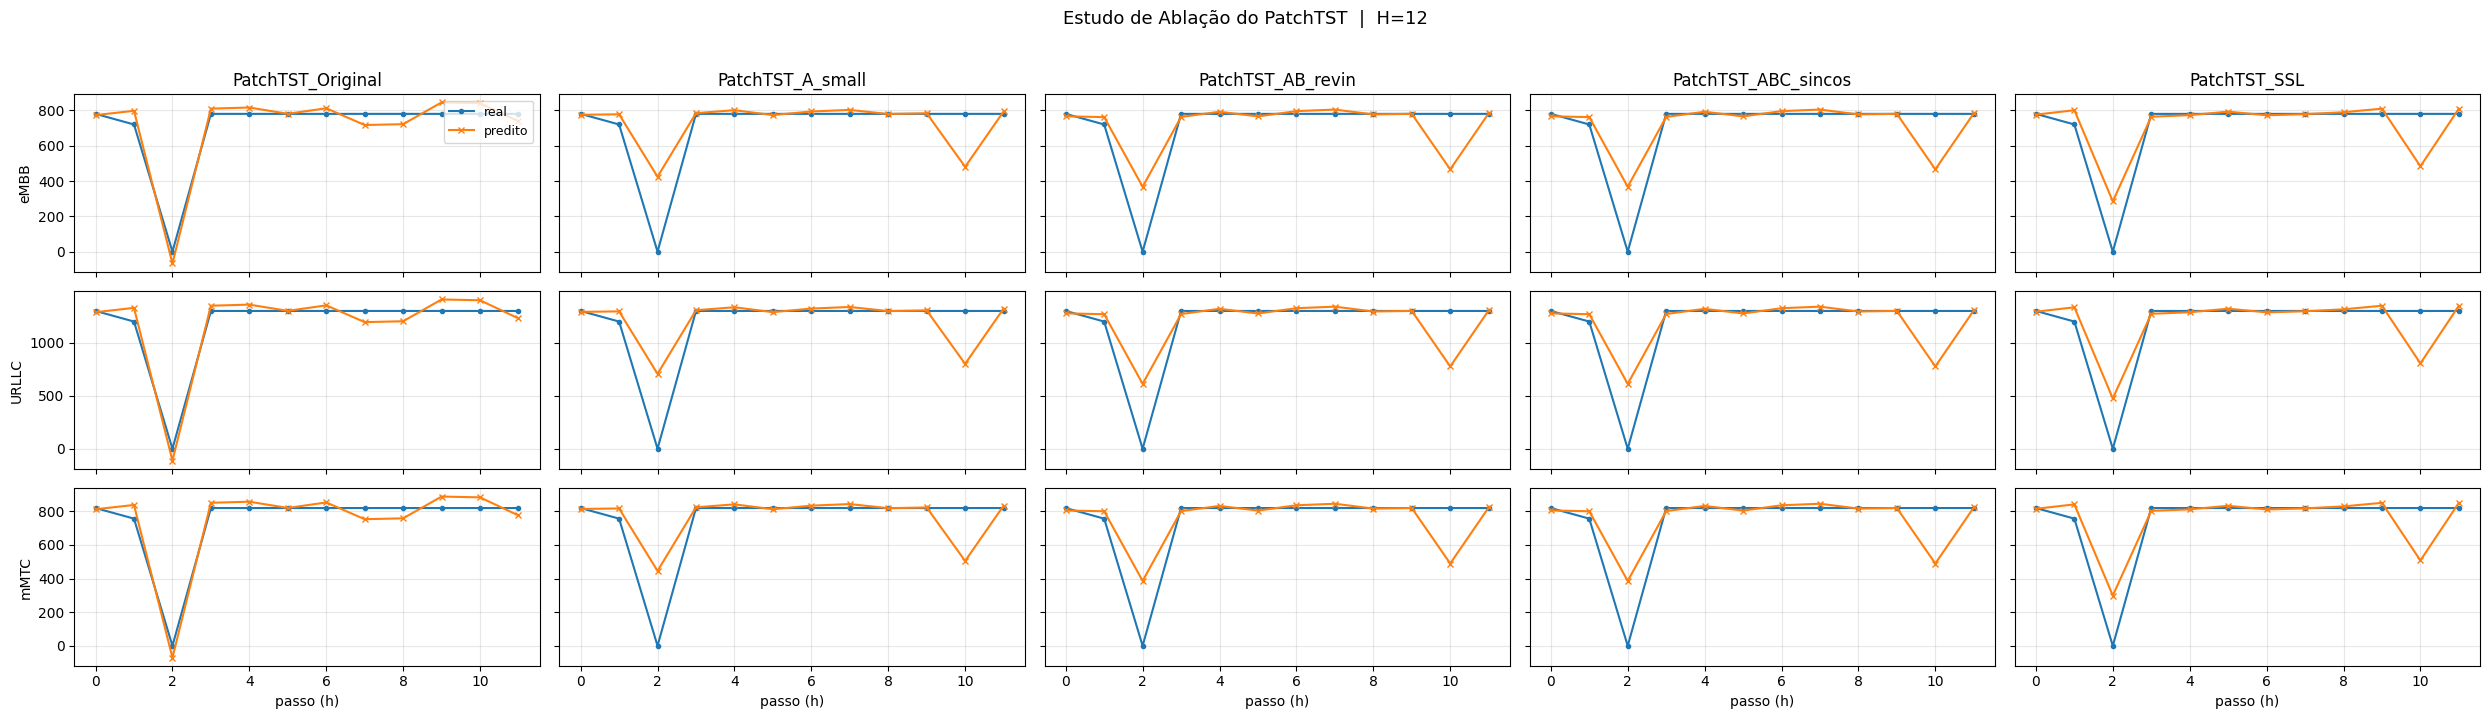

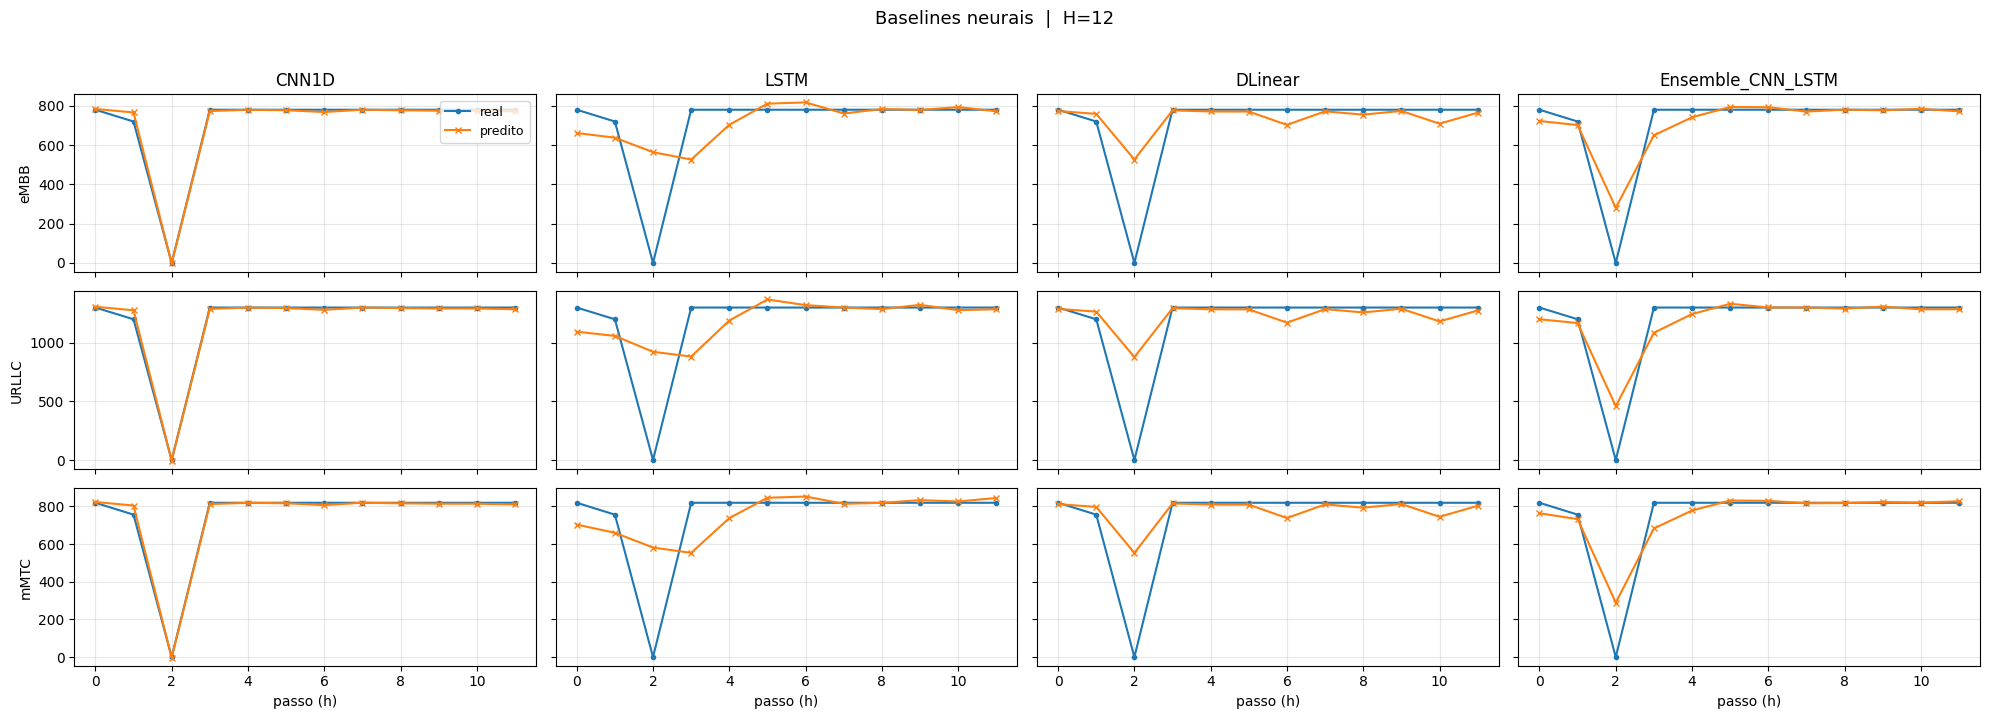

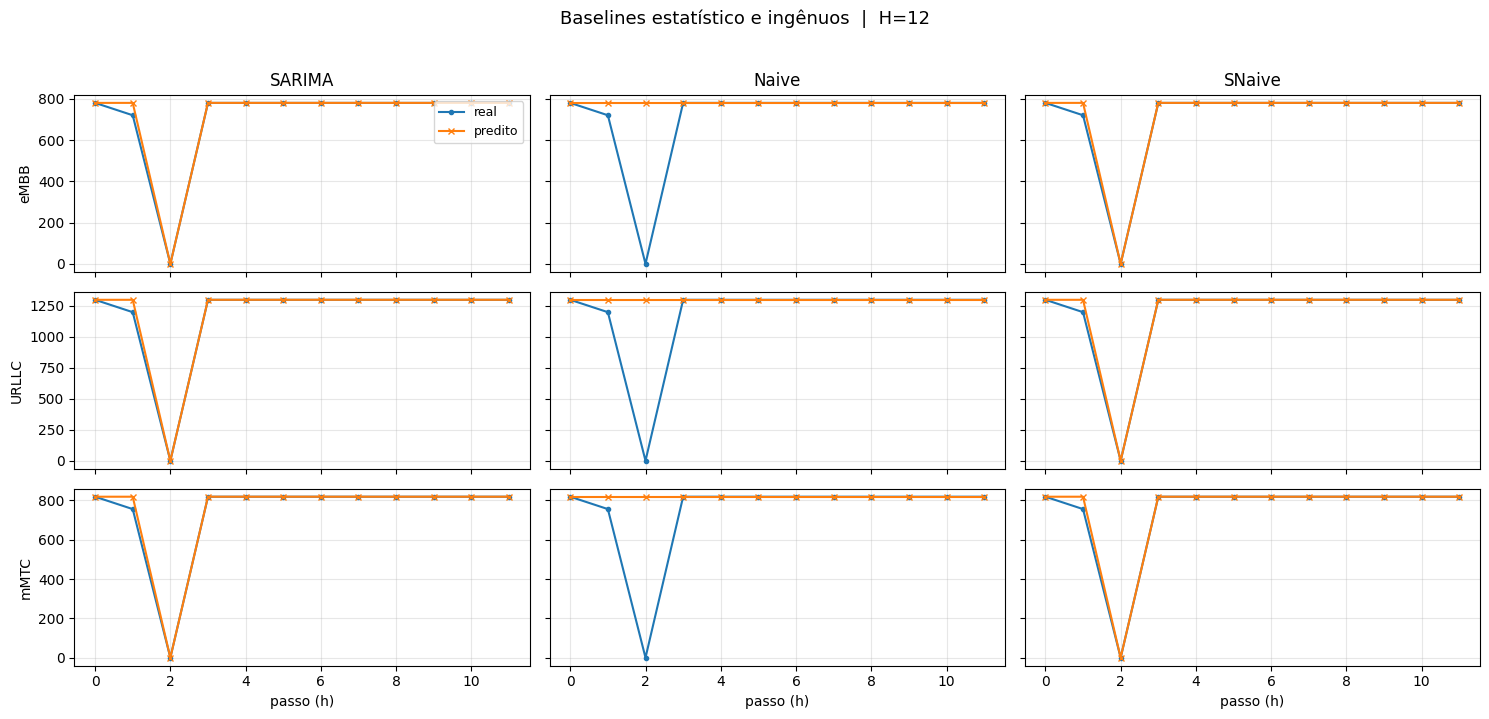

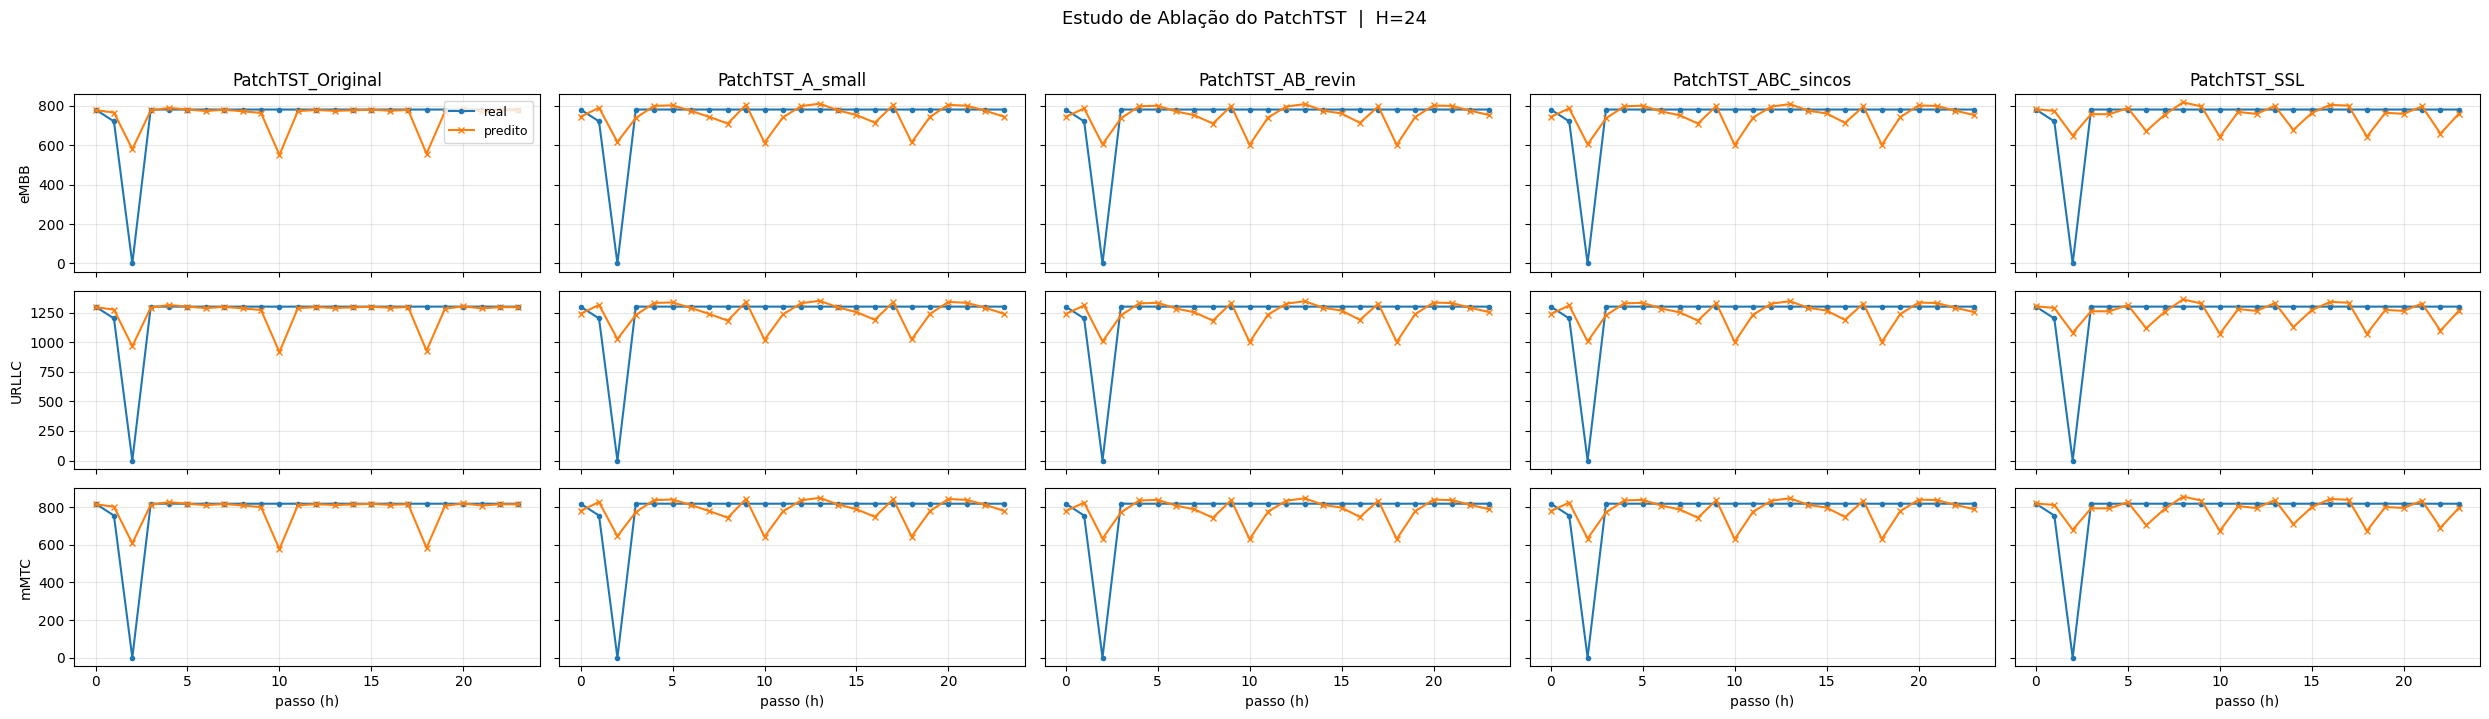

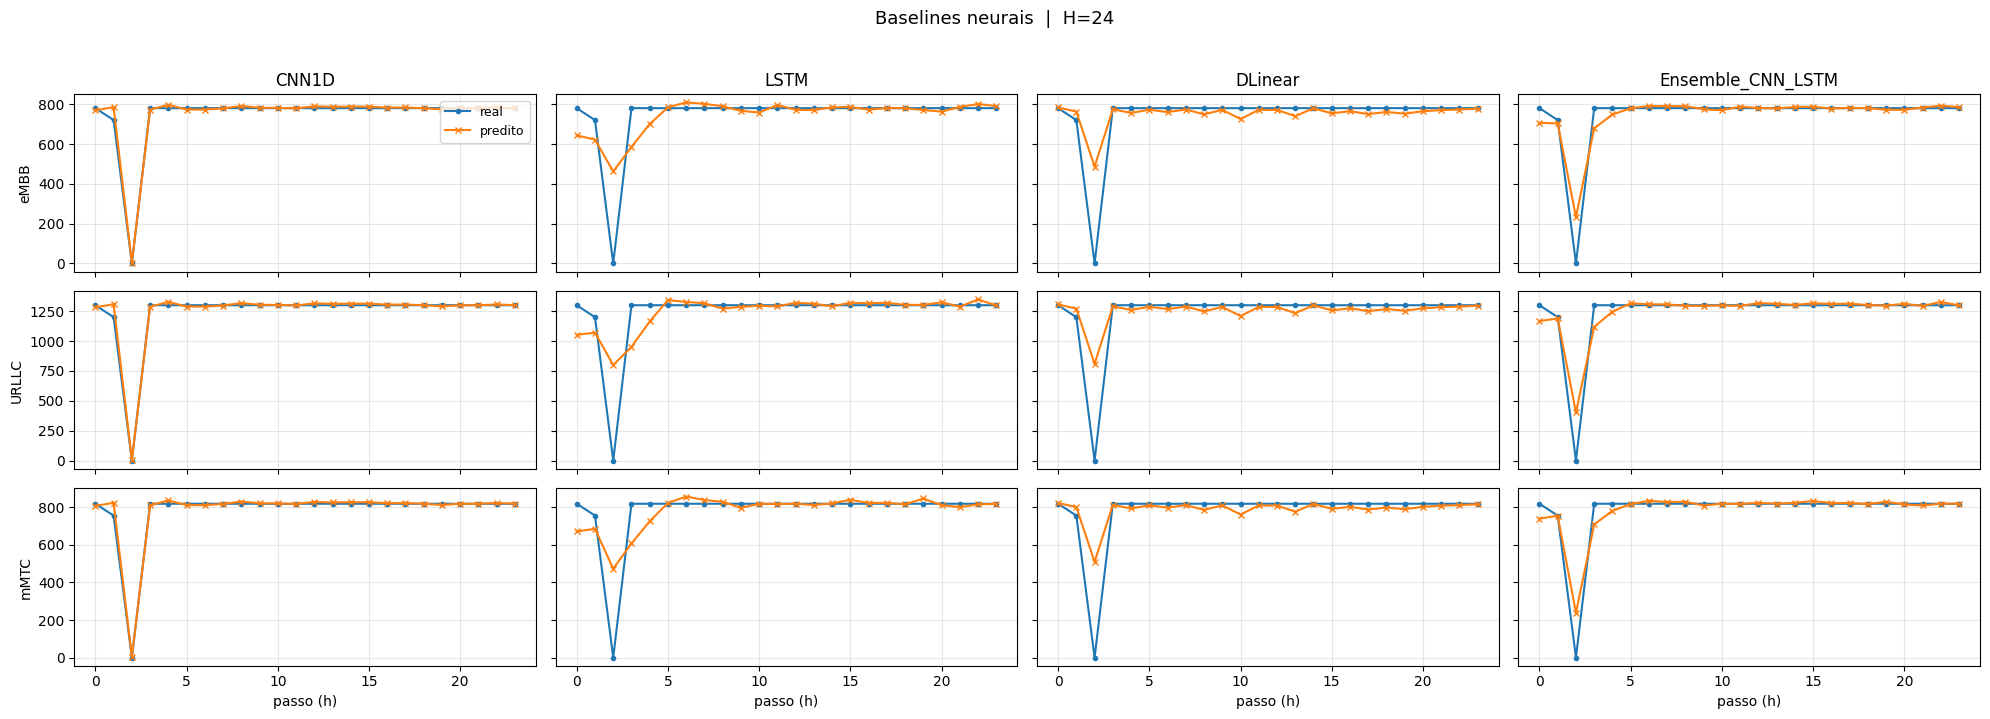

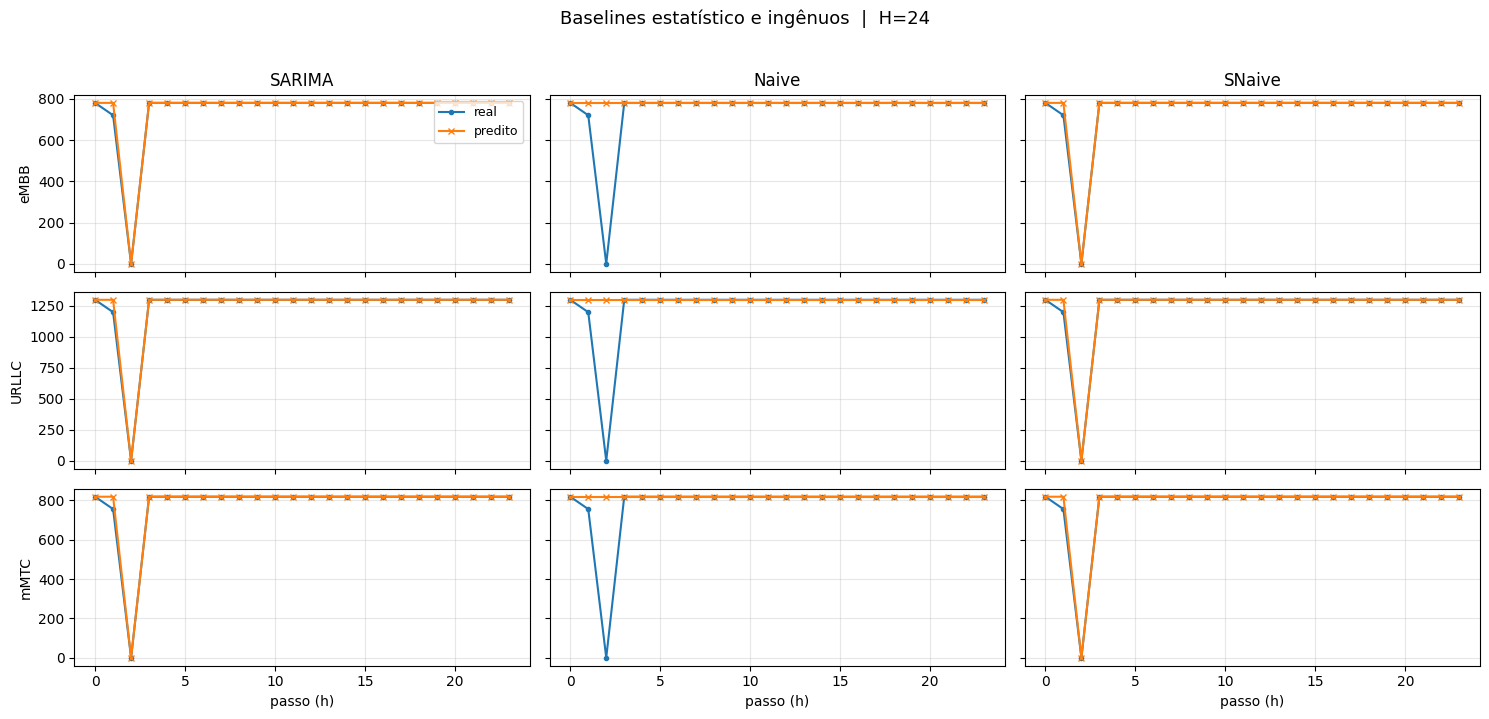

In [ ]:
# Visualização: predição vs verdadeiro para a 1ª janela do teste de cada (modelo, horizonte).
# Com o estudo comparativo expandido temos ~12 modelos em RESULTS, o que tornaria
# uma única grade larga demais. Separamos em três grupos para leitura mais clara:
#   1) Estudo de Ablação do PatchTST (Original -> A -> A+B -> A+B+C -> SSL)
#   2) Baselines neurais (CNN1D, LSTM, DLinear, Ensemble_CNN_LSTM)
#   3) Baselines estatísticos (SARIMA, Naive, SNaive)
sample_idx = 0
horizons = sorted({h for _, h in RESULTS.keys()})

ABLATION_GROUP = [
    'PatchTST_Original',
    'PatchTST_A_small',
    'PatchTST_AB_revin',
    'PatchTST_ABC_sincos',
    'PatchTST_SSL',                # variante com pré-treino auto-supervisionado
]
NEURAL_BASELINES_GROUP   = ['CNN1D', 'LSTM', 'DLinear', 'Ensemble_CNN_LSTM']
STATISTICAL_BASELINES_GROUP = ['SARIMA', 'Naive', 'SNaive']


def _plot_group(group_title: str, model_list: list, h: int):
    # Mantém apenas os modelos efetivamente presentes em RESULTS para esse horizonte
    names = [m for m in model_list if (m, h) in RESULTS]
    if not names:
        return
    n_cols = len(names)
    fig, axes = plt.subplots(len(FEATURES), n_cols,
                             figsize=(5 * n_cols, 7),
                             sharex=True, sharey='row',
                             squeeze=False)  # squeeze=False -> sempre 2D
    fig.suptitle(f'{group_title}  |  H={h}', fontsize=13, y=1.02)

    for col, model_name in enumerate(names):
        res = RESULTS[(model_name, h)]
        y_true = res['trues_real'][sample_idx]   # (H, C)
        y_pred = res['preds_real'][sample_idx]   # (H, C)
        t = np.arange(h)
        for i, feat in enumerate(FEATURES):
            ax = axes[i, col]
            ax.plot(t, y_true[:, i], label='real',    color='tab:blue',   marker='o', ms=3)
            ax.plot(t, y_pred[:, i], label='predito', color='tab:orange', marker='x', ms=4)
            if col == 0:
                ax.set_ylabel(feat)
            ax.grid(True, alpha=0.3)
        axes[0, col].set_title(model_name)

    for ax in axes[-1, :]:
        ax.set_xlabel('passo (h)')
    axes[0, 0].legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()


for h in horizons:
    _plot_group('Estudo de Ablação do PatchTST',     ABLATION_GROUP,             h)
    _plot_group('Baselines neurais',NEURAL_BASELINES_GROUP,    h)
    _plot_group('Baselines estatístico e ingênuos',            STATISTICAL_BASELINES_GROUP,h)

### Etapa 6.1 - Tabela do Estudo de Ablação (PatchTST)

A tabela abaixo isola apenas as 4 variantes do PatchTST em ordem cumulativa, lado a lado com os baselines (`SARIMA`, `CNN1D`, `Naive`, `SNaive`). O objetivo é comprovar **cientificamente** qual técnica reduziu o MSE/MAE do Transformer:

- ΔMSE / ΔMAE = variação **em relação ao passo anterior** da ablação (negativo = melhorou).
- Se ΔMSE for negativo a cada passo, temos a curva descendente esperada que justifica a inclusão da técnica no modelo final.

In [ ]:
# Tabela do estudo de ablação: foco nas 4 variantes do PatchTST + baselines.
ABLATION_ORDER = [
    'PatchTST_Original',     # 1) baseline (alta capacidade, sem RevIN)
    'PatchTST_A_small',      # 2) + Ablação A
    'PatchTST_AB_revin',     # 3) + Ablação A + B
    'PatchTST_ABC_sincos',   # 4) + Ablação A + B + C
    'PatchTST_SSL',          # 5) + SSL (pré-treino mascarado + fine-tuning)
]
BASELINE_MODELS = ['SARIMA', 'CNN1D', 'LSTM', 'DLinear',
                   'Ensemble_CNN_LSTM', 'Naive', 'SNaive']

rows = []
for h in sorted({hh for _, hh in RESULTS.keys()}):
    # 1) Variantes de ablação em ordem cumulativa (com delta vs. passo anterior)
    prev_mse, prev_mae = None, None
    for name in ABLATION_ORDER:
        if (name, h) not in RESULTS:
            continue
        m = RESULTS[(name, h)]['metrics']
        mse, mae = m['MSE_global'], m['MAE_global']
        rows.append({
            'Grupo':   'Ablação PatchTST',
            'Modelo':  name,
            'Horizon': h,
            'MSE':     mse,
            'MAE':     mae,
            'ΔMSE_vs_anterior': None if prev_mse is None else mse - prev_mse,
            'ΔMAE_vs_anterior': None if prev_mae is None else mae - prev_mae,
        })
        prev_mse, prev_mae = mse, mae

    # 2) Baselines (sem delta — referência fixa)
    for name in BASELINE_MODELS:
        if (name, h) not in RESULTS:
            continue
        m = RESULTS[(name, h)]['metrics']
        rows.append({
            'Grupo':   'Baseline',
            'Modelo':  name,
            'Horizon': h,
            'MSE':     m['MSE_global'],
            'MAE':     m['MAE_global'],
            'ΔMSE_vs_anterior': None,
            'ΔMAE_vs_anterior': None,
        })

ablation_table = pd.DataFrame(rows)
print('Estudo de Ablação — MSE/MAE globais (escala real):')
ablation_table.round(4)


Estudo de Ablação — MSE/MAE globais (escala real):


,Grupo,Modelo,Horizon,MSE,MAE,ΔMSE_vs_anterior,ΔMAE_vs_anterior
0,Ablação PatchTST,PatchTST_Original,12,8368.4609,34.4368,NaN,NaN
1,Ablação PatchTST,PatchTST_A_small,12,22167.8672,55.4792,13799.4062,21.0424
2,Ablação PatchTST,PatchTST_AB_revin,12,20511.9727,57.1422,-1655.8945,1.6630
3,Ablação PatchTST,PatchTST_ABC_sincos,12,20511.9727,57.1422,0.0000,0.0000
4,Ablação PatchTST,PatchTST_SSL,12,17844.9609,51.0134,-2667.0117,-6.1288
5,Baseline,SARIMA,12,634.4361,4.3361,NaN,NaN
6,Baseline,CNN1D,12,303.1810,9.0347,NaN,NaN
7,Baseline,LSTM,12,19970.5703,54.4290,NaN,NaN
8,Baseline,DLinear,12,10720.2822,34.6282,NaN,NaN
9,Baseline,Ensemble_CNN_LSTM,12,5436.3770,29.3565,NaN,NaN
